# SUNVEx and WRF-CHEM

This example demonstrates the basics available in MELODIES MONET to 
compare WRF-Chem results against one groundsite in a field campaign.

This example evaluates WRF-Chem against the SUNVEx dataset:
https://csl.noaa.gov/projects/sunvex/

The observational data can be downloaded here: https://csl.noaa.gov/groups/csl7/measurements/2021sunvex/GroundLA/DataDownload/

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "../yaml/control_wrfchem_ground.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2021-08-09-00:00:00',
  'end_time': '2021-08-09-23:59:00',
  'output_dir': './output/sunvex_ground',
  'debug': True},
 'model': {'wrfchem_v4.2': {'files': '/wrk/d2/rschwantes/MM_example_data/sunvex_base/*',
   'mod_type': 'wrfchem',
   'mod_kwargs': {'mech': 'racm_esrl_vcp'},
   'mapping': {'pasadena_ground': {'o3': 'O3_NOAA_NOxCaRD_ppbv',
     'no': 'NO_NOAA_NOxCaRD_ppbv',
     'no2': 'NO2_NOAA_NOxCaRD_ppbv'}},
   'plot_kwargs': {'color': 'dodgerblue', 'marker': '^', 'linestyle': ':'}}},
 'obs': {'pasadena_ground': {'filename': '/wrk/d2/rschwantes/MM_example_data/obs/sunvex/recap-NOAANOxCaRD-NO2-NOx-NO-NOy-Ox-O3_CITN_20210809_R0.ict',
   'obs_type': 'ground',
   'ground_coordinate': {'latitude': 34.140289, 'longitude': -118.125371},
   'variables': {'O3_NOAA_NOxCaRD_ppbv': {'unit_scale': 1,
     'unit_scale_method': '*',
     'nan_value': -7777,
     'LLOD_value': -8888,
     'LLOD_setvalue': 0.0,
     'ylabel_plot': 'Ozone NOxCaRD (ppb)',
     'vmin_plot

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='../yaml/control_wrfchem_ground.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2021-08-09 00:00:00'),
    end_time=Timestamp('2021-08-09 23:59:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/sunvex_ground',
    output_dir_save='./output/sunvex_ground',
    output_dir_read='./output/sunvex_ground',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

wrfchem
/wrk/d2/rschwantes/MM_example_data/sunvex_base/*
**** Reading WRF-Chem model output...


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

In [7]:
an.models

{'wrfchem_v4.2': model(
     model='wrfchem',
     is_global=False,
     radius_of_influence=1000000.0,
     mod_kwargs={'mech': 'racm_esrl_vcp', 'var_list': ['o3', 'no2', 'no', 'pres', 'height', 'tk', 'height_agl', 'PSFC', 'zstag']},
     file_str='/wrk/d2/rschwantes/MM_example_data/sunvex_base/*',
     label='wrfchem_v4.2',
     obj=...,
     extra_calc=None,
     mapping={'pasadena_ground': {'o3': 'O3_NOAA_NOxCaRD_ppbv', 'no': 'NO_NOAA_NOxCaRD_ppbv', 'no2': 'NO2_NOAA_NOxCaRD_ppbv'}},
     variable_dict=None,
     label='wrfchem_v4.2',
     ...
 )}

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [8]:
an.models['wrfchem_v4.2'].obj

<xarray.Dataset> Size: 5GB
Dimensions:        (y: 324, x: 264, time: 30, z: 50, bottom_top_stag: 51)
Coordinates:
    longitude      (y, x) float32 342kB -121.8 -121.7 -121.7 ... -113.5 -113.4
    latitude       (y, x) float32 342kB 30.29 30.3 30.3 ... 43.77 43.78 43.79
  * time           (time) datetime64[ns] 240B 2021-08-09 ... 2021-08-10T05:00:00
Dimensions without coordinates: y, x, z, bottom_top_stag
Data variables:
    o3             (time, z, y, x) float32 513MB 21.0 21.0 ... 1.685e+03
    no2            (time, z, y, x) float32 513MB 0.06771 0.0678 ... 0.8363
    no             (time, z, y, x) float32 513MB 0.03022 0.03015 ... 3.736e-08
    pres_pa_mid    (time, z, y, x) float32 513MB 1.012e+05 ... 5.584e+03
    alt_msl_m_mid  (time, z, y, x) float32 513MB 11.15 11.15 ... 2.034e+04
    temperature_k  (time, z, y, x) float32 513MB 291.5 291.5 ... 216.9 216.9
    alt_agl_m_mid  (time, z, y, x) float32 513MB 11.14 11.14 ... 1.856e+04
    surfpres_pa    (time, y, x) float32 10MB 1.014e+05 1.014e+05 ... 8.235e+04
    zstag          (time, bottom_top_stag, y, x) float32 523MB 0.01339 ... 2....
    dz_m           (time, z, y, x) float32 513MB 22.28 22.28 ... 1.333e+03
Attributes: (12/15)
    FieldType:                 104
    MemoryOrder:               XYZ
    description:               O3 mixing ratio
    units:                     ppmv
    stagger:                   
    coordinates:               XLONG XLAT XTIME
    ...                        ...
    MOAD_CEN_LAT:              37.097275
    STAND_LON:                 -97.0
    MAP_PROJ:                  1
    CEN_LAT:                   37.09727
    CEN_LON:                   -117.99237
    mapping_tables_to_airnow:  {'OZONE': 'o3', 'PM2.5': 'PM2_5_DRY', 'PM10': ...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [9]:
an.open_obs()

In [10]:
an.obs

{'pasadena_ground': observation(
     obs='pasadena_ground',
     label='pasadena_ground',
     file='/wrk/d2/rschwantes/MM_example_data/obs/sunvex/recap-NOAANOxCaRD-NO2-NOx-NO-NOy-Ox-O3_CITN_20210809_R0.ict',
     obj=...,
     extra_calc=None,
     type='pt_src',
     sat_type=None,
     sat_method=None,
     data_proc=None,
     variable_dict={'O3_NOAA_NOxCaRD_ppbv': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'Ozone NOxCaRD (ppb)', 'vmin_plot': 0.0, 'vmax_plot': 120.0}, 'NO_NOAA_NOxCaRD_ppbv': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'NO NOxCaRD (ppb)', 'vmin_plot': 0.0, 'vmax_plot': 10.0}, 'NO2_NOAA_NOxCaRD_ppbv': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'NO2 NOxCaRD (ppb)', 'vmin_plot': 0.0, 'vmax_plot': 30.0}},
     resample=None,
     time_va

In [11]:
an.obs['pasadena_ground'].obj

<xarray.Dataset> Size: 127kB
Dimensions:                (time: 1440)
Coordinates:
  * time                   (time) datetime64[ns] 12kB 2021-08-09 ... 2021-08-...
Data variables:
    StartTime_UTC          (time) float64 12kB 0.0 60.0 ... 8.628e+04 8.634e+04
    StopTime_UTC           (time) float64 12kB 60.0 120.0 ... 8.634e+04 8.64e+04
    NO_NOAA_NOxCaRD_ppbv   (time) float64 12kB 0.381 0.34 0.372 ... 0.251 0.686
    NO2_NOAA_NOxCaRD_ppbv  (time) float64 12kB 3.921 3.911 4.259 ... 3.144 4.301
    NOy_NOAA_NOxCaRD_ppbv  (time) float64 12kB 9.959 9.901 9.757 ... 7.795 8.084
    O3_NOAA_NOxCaRD_ppbv   (time) float64 12kB 81.01 79.67 80.34 ... 60.7 58.85
    NOx_NOAA_NOxCaRD_ppbv  (time) float64 12kB 4.303 4.251 4.631 ... 3.395 4.987
    Ox_NOAA_NOxCaRD_ppbv   (time) float64 12kB 84.93 83.58 84.6 ... 63.85 63.16
    latitude               (time) float64 12kB 34.14 34.14 34.14 ... 34.14 34.14
    longitude              (time) float64 12kB -118.1 -118.1 ... -118.1 -118.1
Attributes: (12/22)
    source:               NOxCaRD Instrument
    Date Revised:         2022-12-14 00:00:00
    mission:              SUNVEx/RECAP
    organization:         NOAA Chemical Sciences Laboratory
    PI:                   Kristen Zuraski, Michael A. Robinson, Jeff Peischl,...
    PI_CONTACT_INFO:      Address
    ...                   ...
    DM_CONTACT_INFO:      Data Manager
    PROJECT_INFO:         Project Info
    STIPULATIONS_ON_USE:  Use of these data require prior ok from PI.
    OTHER_COMMENTS:       Data are reported as 1-minute measurements, but are...
    REVISION:             R0
    R0:                   Final Data; RA

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [12]:
%%time

an.pair_data()

1, in pair data
After pairing:        StartTime_UTC  StopTime_UTC                time  NO_NOAA_NOxCaRD_ppbv  \
0               0.0          60.0 2021-08-09 00:00:00                 0.381   
1              60.0         120.0 2021-08-09 00:01:00                 0.340   
2             120.0         180.0 2021-08-09 00:02:00                 0.372   
3             180.0         240.0 2021-08-09 00:03:00                 0.347   
4             240.0         300.0 2021-08-09 00:04:00                 0.278   
...             ...           ...                 ...                   ...   
1435        86100.0       86160.0 2021-08-09 23:55:00                 0.135   
1436        86160.0       86220.0 2021-08-09 23:56:00                 0.265   
1437        86220.0       86280.0 2021-08-09 23:57:00                 0.175   
1438        86280.0       86340.0 2021-08-09 23:58:00                 0.251   
1439        86340.0       86400.0 2021-08-09 23:59:00                 0.686   

      NO2_NOAA_NOxC

In [13]:
an.paired

{'pasadena_ground_wrfchem_v4.2': pair(
     type='ground',
     radius_of_influence=None,
     obs='pasadena_ground',
     model='wrfchem_v4.2',
     model_vars=['o3', 'no', 'no2'],
     obs_vars=['O3_NOAA_NOxCaRD_ppbv', 'NO_NOAA_NOxCaRD_ppbv', 'NO2_NOAA_NOxCaRD_ppbv'],
     filename='pasadena_ground_wrfchem_v4.2.nc',
 )}

In [14]:
an.paired['pasadena_ground_wrfchem_v4.2'].obj

<xarray.Dataset> Size: 161kB
Dimensions:                (time: 1440, x: 1)
Coordinates:
  * time                   (time) datetime64[ns] 12kB 2021-08-09 ... 2021-08-...
Dimensions without coordinates: x
Data variables: (12/13)
    StartTime_UTC          (time, x) float64 12kB 0.0 60.0 ... 8.634e+04
    StopTime_UTC           (time, x) float64 12kB 60.0 120.0 ... 8.64e+04
    NO_NOAA_NOxCaRD_ppbv   (time, x) float64 12kB 0.381 0.34 ... 0.251 0.686
    NO2_NOAA_NOxCaRD_ppbv  (time, x) float64 12kB 3.921 3.911 ... 3.144 4.301
    NOy_NOAA_NOxCaRD_ppbv  (time, x) float64 12kB 9.959 9.901 ... 7.795 8.084
    O3_NOAA_NOxCaRD_ppbv   (time, x) float64 12kB 81.01 79.67 ... 60.7 58.85
    ...                     ...
    Ox_NOAA_NOxCaRD_ppbv   (time, x) float64 12kB 84.93 83.58 ... 63.85 63.16
    latitude               (time, x) float64 12kB 34.14 34.14 ... 34.14 34.14
    longitude              (time, x) float64 12kB -118.1 -118.1 ... -118.1
    o3                     (time, x) float64 12kB 75.17 75.02 ... 71.44 71.36
    no                     (time, x) float64 12kB 0.7282 0.7324 ... 1.083 1.084
    no2                    (time, x) float64 12kB 4.44 4.479 ... 6.128 6.137

## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

Reference std: 23.627276914547114
Reference std: 0.908154473046842
Reference std: 2.2600042026198595
CPU times: user 6.43 s, sys: 675 ms, total: 7.11 s
Wall time: 7.32 s


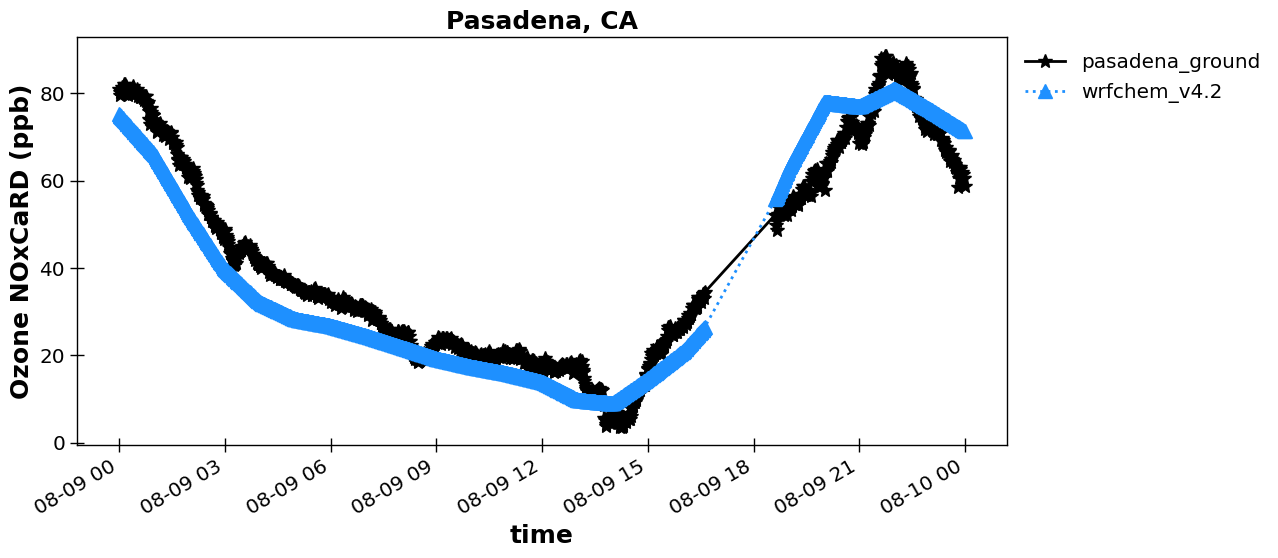

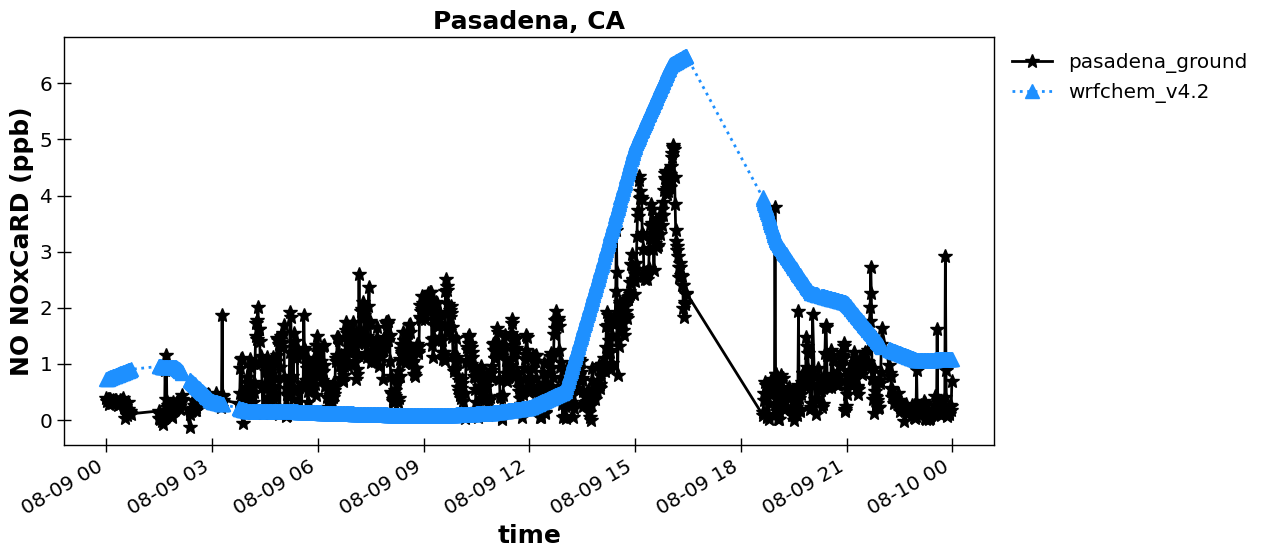

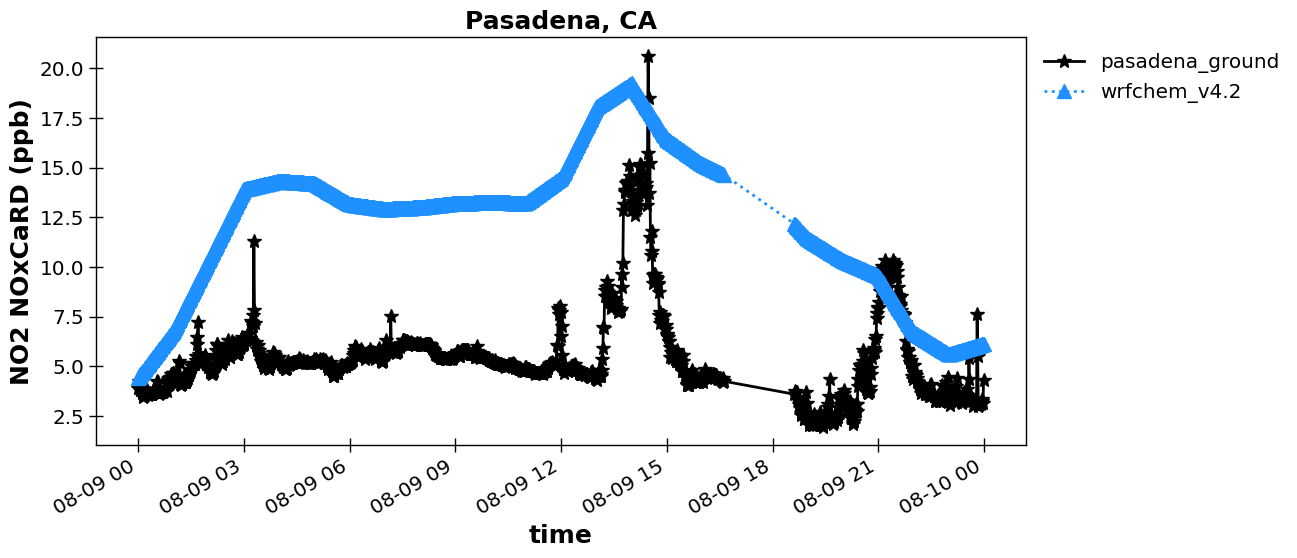

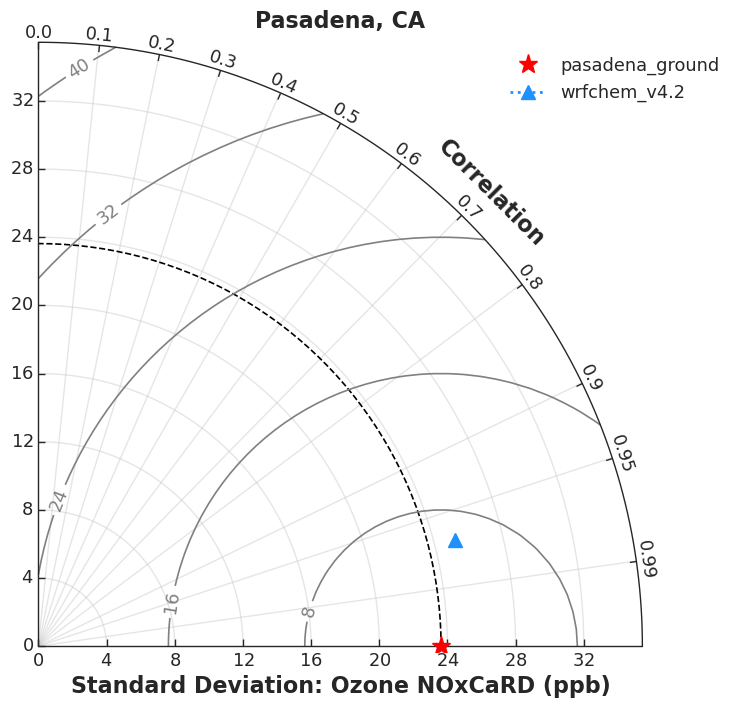

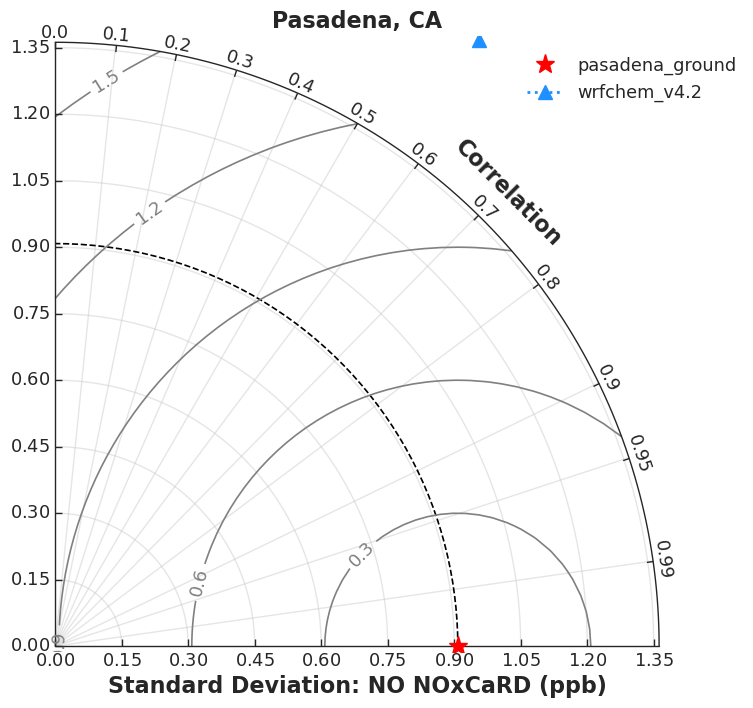

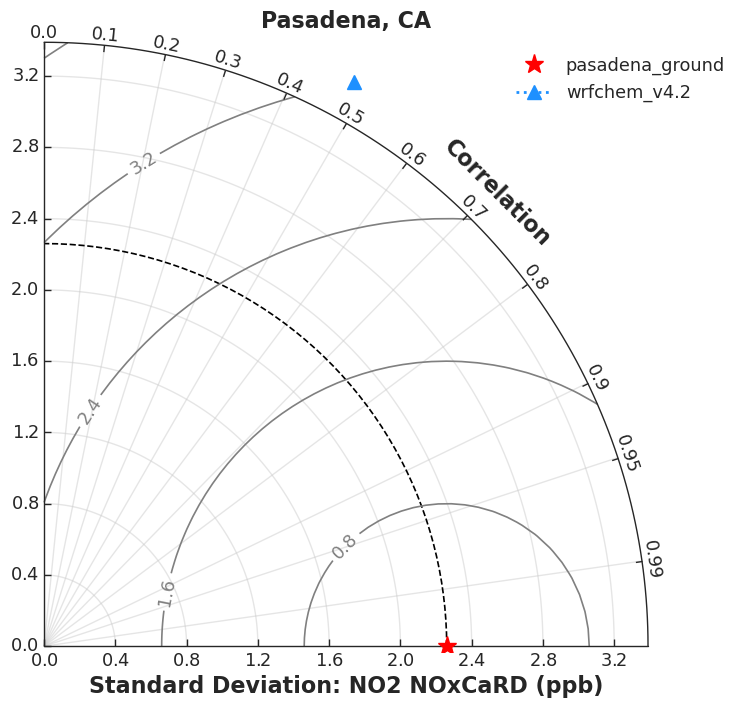

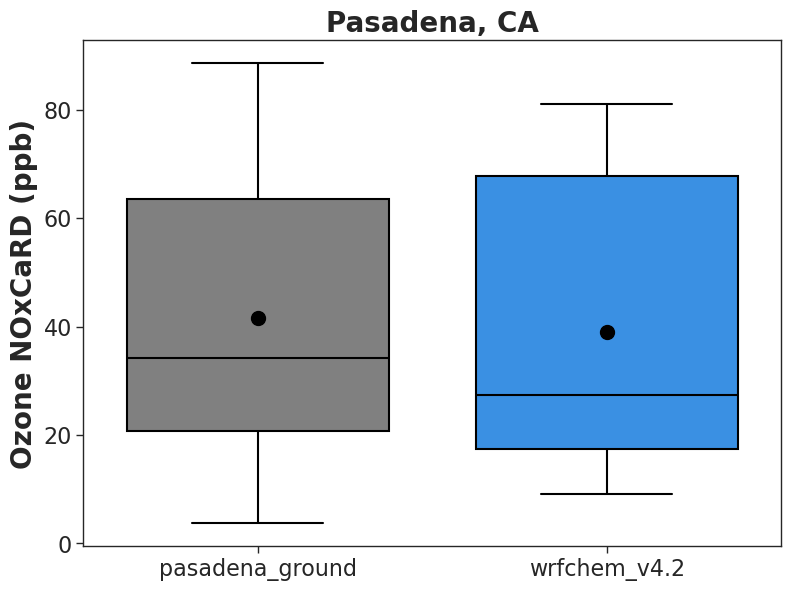

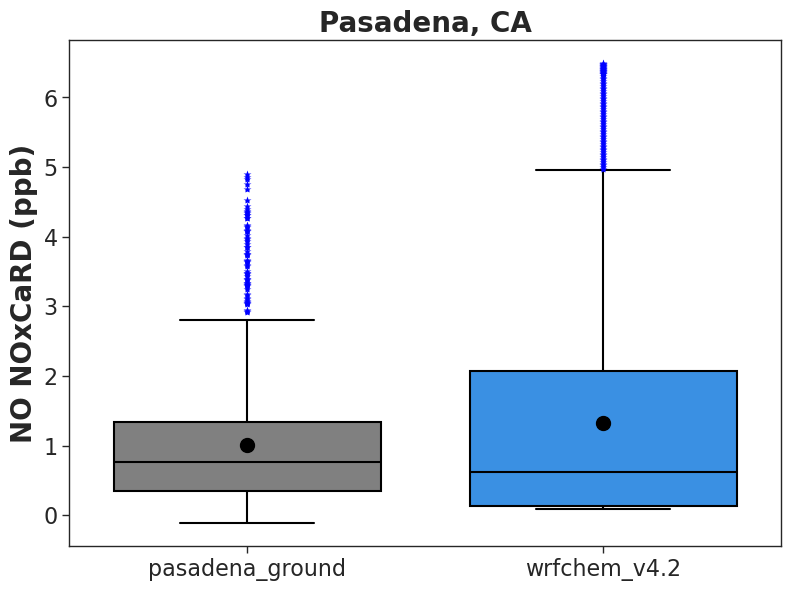

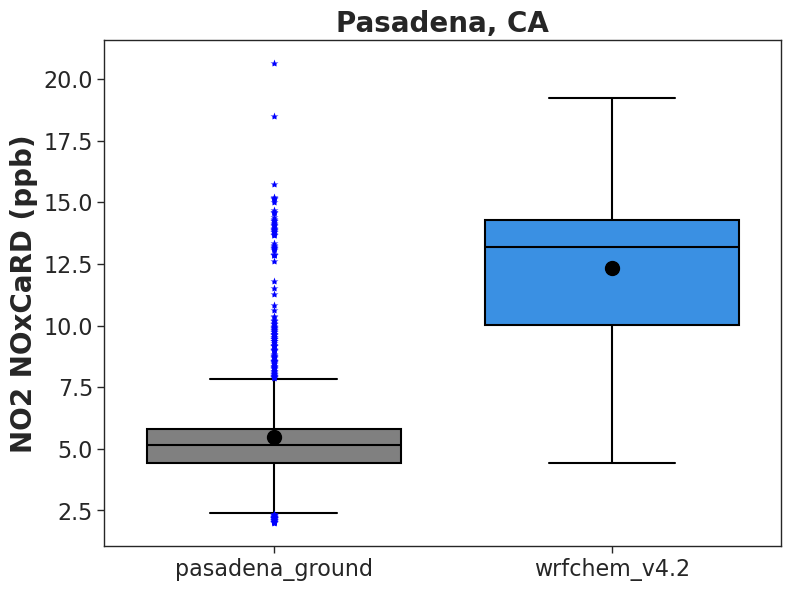

In [15]:
%%time

an.plotting()

In [16]:
%%time

an.stats()

CPU times: user 60.7 ms, sys: 9.28 ms, total: 70 ms
Wall time: 77.8 ms
